# Notebook 2: Wind Reliability Analysis

## Objective
Analyze historical actual generation of wind power and recommend how many MW of wind power can be reliably expected to meet electricity demand.

## Analysis Tasks
1. Analyze wind generation patterns and variability
2. Calculate reliability metrics at different thresholds
3. Make a recommendation for reliable MW capacity
4. Support recommendation with evidence and reasoning

---


## 1. Setup and Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.1 Data Fetching Function

In [ ]:
def fetch_wind_generation(start_date, end_date):
   
    url = f"https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream?publishDateTimeFrom={start_date}T00%3A00%3A00Z&publishDateTimeTo={end_date}T23%3A59%3A59Z&fuelType=WIND"
    
    response = requests.get(url)
    if response.status_code != 200:
        raise Exception(f"API Error: {response.status_code}")
    
    data = response.json()
    df = pd.DataFrame(data)
    
    # Keep latest publishTime for each startTime
    df = df.sort_values('publishTime').groupby('startTime').last().reset_index()
    df['startTime'] = pd.to_datetime(df['startTime'])
    
    return df[['startTime', 'generation']]


def fetch_multiple_months(months_list):
   
    all_data = []
    for start, end in months_list:
        print(f"Fetching {start} to {end}...")
        df = fetch_wind_generation(start, end)
        all_data.append(df)
    
    combined = pd.concat(all_data, ignore_index=True)
    combined = combined.sort_values('startTime').reset_index(drop=True)
    return combined


print("Data fetching functions defined!")

Data fetching functions defined!


### 1.2 Load Historical Data


In [3]:
DATA_PERIODS = [
    ('2024-01-01', '2024-01-31'),
    ('2023-12-01', '2023-12-31'),
    ('2023-11-01', '2023-11-30')
]
wind_df = fetch_multiple_months(DATA_PERIODS)
print(f"\nTotal records: {len(wind_df)}")
display(wind_df.describe())

Fetching 2024-01-01 to 2024-01-31...
Fetching 2023-12-01 to 2023-12-31...
Fetching 2023-11-01 to 2023-11-30...

Total records: 4415


,generation
count,4415.000000
mean,9854.567837
std,4207.712744
min,0.000000
25%,6684.000000
50%,10147.000000
75%,13524.000000
max,17406.000000


---

## 2. Wind Generation Patterns Analysis


In [4]:
summary_stats = wind_df['generation'].describe()
display(summary_stats)
cv = summary_stats['std'] / summary_stats['mean']
print(f"Coefficient of Variation (CV): {cv:.2f}")

,generation
count,4415.000000
mean,9854.567837
std,4207.712744
min,0.000000
25%,6684.000000
50%,10147.000000
75%,13524.000000
max,17406.000000


Coefficient of Variation (CV): 0.43


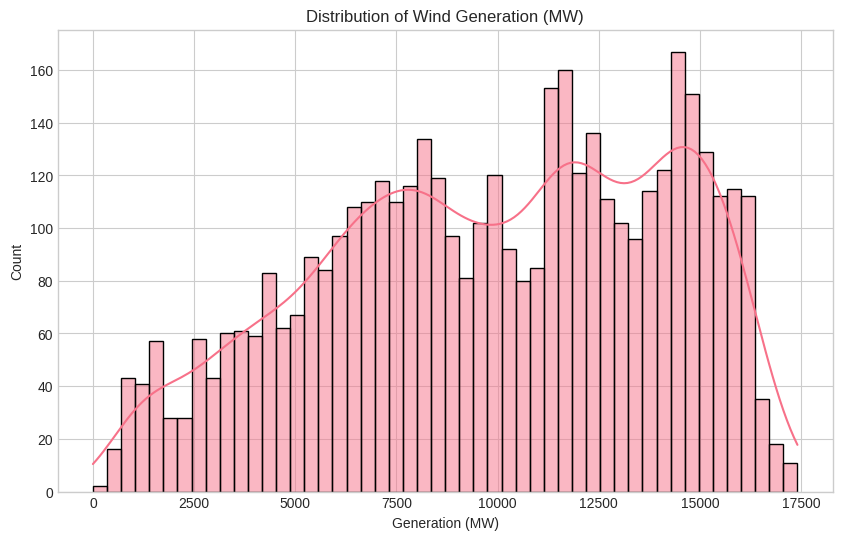

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(wind_df['generation'], bins=50, kde=True)
plt.title('Distribution of Wind Generation (MW)')
plt.xlabel('Generation (MW)')
plt.show()

---

## 3. Variability Analysis


,ramp
count,4414.000000
mean,1.873131
std,457.924507
min,-12083.000000
25%,-187.000000
50%,-3.000000
75%,183.000000
max,12439.000000


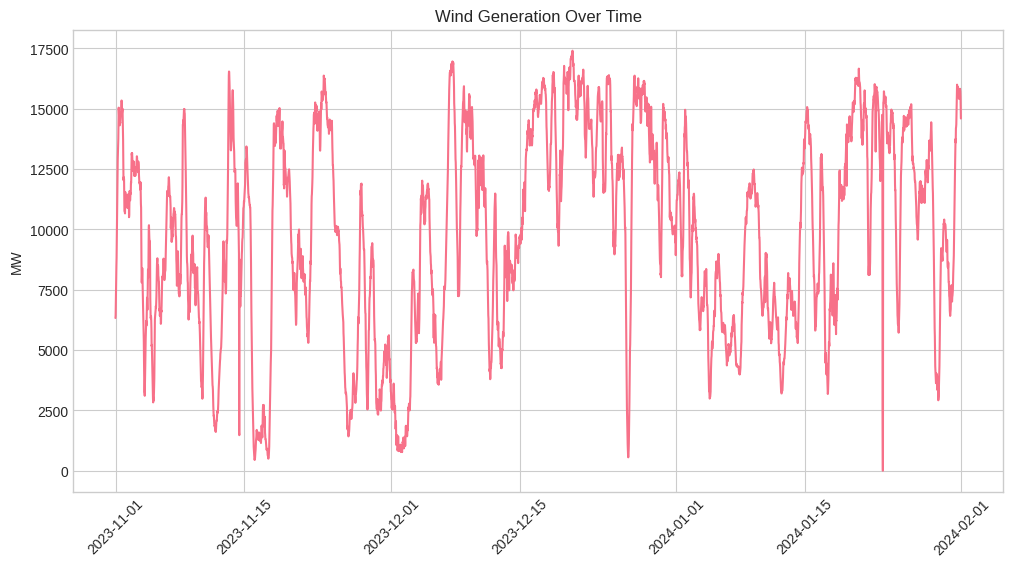

In [6]:
wind_df['ramp'] = wind_df['generation'].diff()
display(wind_df['ramp'].describe())
plt.figure(figsize=(12, 6))
plt.plot(wind_df['startTime'], wind_df['generation'])
plt.title('Wind Generation Over Time')
plt.ylabel('MW')
plt.xticks(rotation=45)
plt.show()

In [7]:
thresholds = [1000, 2000, 5000]
for t in thresholds:
    pct_below = (wind_df['generation'] < t).mean() * 100
    print(f"% of time below {t} MW: {pct_below:.2f}%")

% of time below 1000 MW: 1.29%
% of time below 2000 MW: 4.05%
% of time below 5000 MW: 14.99%


---

## 4. Reliability Metrics


In [8]:
# Assuming approx 28 GW (28,000 MW) installed capacity in UK
installed_capacity_mw = 28000
capacity_factor = wind_df['generation'].mean() / installed_capacity_mw * 100
print(f"Average Capacity Factor: {capacity_factor:.2f}%")

Average Capacity Factor: 35.19%


In [9]:

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]


In [10]:
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
percentile_values = np.percentile(wind_df['generation'].dropna(), percentiles)
p_df = pd.DataFrame({'Percentile': percentiles, 'MW Threshold (Exceeded X% of time)': percentile_values[::-1]}) # reversed since P99 means 99% of variables exceed it
display(p_df)

,Percentile,MW Threshold (Exceeded X% of time)
0,1,16517.0
1,5,15855.3
2,10,15214.4
3,25,13524.0
4,50,10147.0
5,75,6684.0
6,90,3850.2
7,95,2472.5
8,99,908.0
